In [6]:
import torch
import time 

import matplotlib.pyplot as plt
import numpy as np

from oracle.architectures import GRU_MD_Improved, GRU_MD_MM_Improved, GRU_Improved, GRU, GRU_MD
from oracle.taxonomies import BTS_Taxonomy, ORACLE_Taxonomy

In [3]:
taxonomy = BTS_Taxonomy()
elasticc_taxonomy = ORACLE_Taxonomy()

In [ ]:


bts_oracle2 = GRU_MD_Improved(taxonomy)
bts_oracle2_omni = GRU_MD_MM_Improved(taxonomy, image_model_dir=None, lc_md_model_dir=None)
bts_oracle2_lite = GRU_Improved(taxonomy)

elasticc_oracle2 = GRU_MD_Improved(elasticc_taxonomy, static_feature_dim=18)
elasticc_oracle2_lite = GRU_Improved(elasticc_taxonomy)

bts_oracle2_lite.eval()
bts_oracle2.eval()
bts_oracle2_omni.eval()
elasticc_oracle2.eval()
elasticc_oracle2_lite.eval()



In [16]:
F1_scores = {
    "Oracle-2 Lite (BTS)": 0.59,
    "Oracle-2 (BTS)": 0.70,
    "Oracle-2 Omni (BTS)": 0.73,
    "Oracle-2 Lite (ELAsTiCC)": 0.83,
    "Oracle-2 (ELAsTiCC)": 0.88,
}

models = {
    "Oracle-2 Lite (BTS)": bts_oracle2_lite,
    "Oracle-2 (BTS)": bts_oracle2,
    "Oracle-2 Omni (BTS)": bts_oracle2_omni,
    "Oracle-2 Lite (ELAsTiCC)": elasticc_oracle2_lite,
    "Oracle-2 (ELAsTiCC)": elasticc_oracle2
}

colors = {
    'Oracle-2 Lite (BTS)': '#994882',
    'Oracle-2 (BTS)': '#008080',
    'Oracle-2 Omni (BTS)': '#FF6645',
    'Oracle-2 Lite (ELAsTiCC)': "crimson",
    'Oracle-2 (ELAsTiCC)': "steelblue",
}

markers = {
    'Oracle-2 Lite (BTS)': 's',
    'Oracle-2 (BTS)': 'D',
    'Oracle-2 Omni (BTS)': 'o',
    'Oracle-2 Lite (ELAsTiCC)': "X",
    'Oracle-2 (ELAsTiCC)': "*",
}

mean_times = {}
std_times = {}

In [ ]:
# Benchmarking the throughput of the two models
num_iterations = 5
batch_size = 1

for m in models:
    batch = {
        "ts": torch.randn(batch_size, 5, 5),  # (batch_size, seq_len, num_features)
        "length": torch.from_numpy(np.array([5] * batch_size)),  # (batch_size,)
        "postage_stamp": torch.randn(batch_size, 3, 224, 224)  # (batch_size, num_channels, height, width)
    }
    if 'BTS' in m:
        batch["static"] = torch.randn(batch_size, 30)
    else:
        batch["static"] = torch.randn(batch_size, 18)

    model = models[m]
    times = []

    for _ in range(num_iterations):
        start_time = time.time()
        model(batch)
        end_time = time.time()
        times.append(end_time - start_time)
    mean_times[m] = np.mean(times)
    std_times[m] = np.std(times)
    

In [23]:
mean_times

{'Oracle-2 Lite (BTS)': np.float64(1.1778279304504395),
 'Oracle-2 (BTS)': np.float64(1.6407146453857422),
 'Oracle-2 Omni (BTS)': np.float64(5.819877862930298),
 'Oracle-2 Lite (ELAsTiCC)': np.float64(1.1026494979858399),
 'Oracle-2 (ELAsTiCC)': np.float64(1.5799765586853027)}

In [24]:
std_times

{'Oracle-2 Lite (BTS)': np.float64(0.2092429739567509),
 'Oracle-2 (BTS)': np.float64(0.15133999102650764),
 'Oracle-2 Omni (BTS)': np.float64(2.8715510240889244),
 'Oracle-2 Lite (ELAsTiCC)': np.float64(0.41280380013071927),
 'Oracle-2 (ELAsTiCC)': np.float64(0.4310384833803476)}

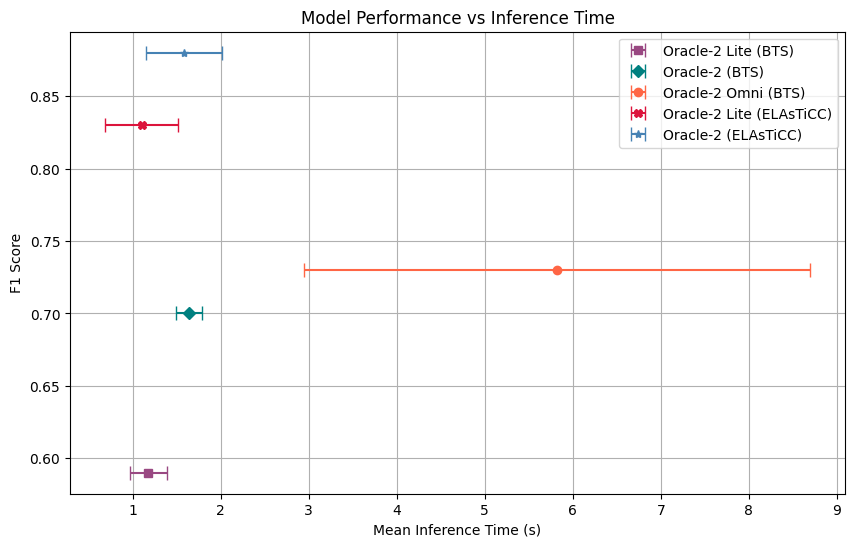

In [25]:
# make f1 vs throughput plot
plt.figure(figsize=(10, 6))
for m in models:
    plt.errorbar(mean_times[m], F1_scores[m], xerr=std_times[m], fmt=markers[m], color=colors[m], label=m, capsize=5)
plt.xlabel('Mean Inference Time (s)')
plt.ylabel('F1 Score')
plt.title('Model Performance vs Inference Time')
plt.legend()
plt.grid()
plt.show()